Algorithm Trading BackTest

Code contains the Bollinger Bands and calculates a 20 day period window and the upper and lower bands

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

data = yf.download("SPY", start="2015-01-01")[["Close"]]

data['SMA'] = data['Close'].rolling(window=20).mean()

        # Calculate the 20-period Standard Deviation (SD)
data['SD'] = data['Close'].rolling(window=20).std()

        # Calculate the Upper Bollinger Band (UB) and Lower Bollinger Band (LB)
data['UB'] = data['SMA'] + 2 * data['SD']
data['LB'] = data['SMA'] - 2 * data['SD']

print("SMA:", data['SMA'])
print("SD:", data['SD'])
print("Upper Band:", data['UB'])
print("Lower Band:", data['LB'])

C:\Users\matth\AppData\Local\Temp\ipykernel_25664\710003316.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SPY", start="2015-01-01")[["Close"]]
[*********************100%***********************]  1 of 1 completed

SMA: Date
2015-01-02           NaN
2015-01-05           NaN
2015-01-06           NaN
2015-01-07           NaN
2015-01-08           NaN
                 ...    
2025-09-15    645.111465
2025-09-16    645.944156
2025-09-17    646.909979
2025-09-18    648.114142
2025-09-19    649.609500
Name: SMA, Length: 2695, dtype: float64
SD: Date
2015-01-02         NaN
2015-01-05         NaN
2015-01-06         NaN
2015-01-07         NaN
2015-01-08         NaN
                ...   
2025-09-15    6.577681
2025-09-16    7.130210
2025-09-17    7.309361
2025-09-18    7.459610
2025-09-19    7.435222
Name: SD, Length: 2695, dtype: float64
Upper Band: Date
2015-01-02           NaN
2015-01-05           NaN
2015-01-06           NaN
2015-01-07           NaN
2015-01-08           NaN
                 ...    
2025-09-15    658.266827
2025-09-16    660.204575
2025-09-17    661.528701
2025-09-18    663.033363
2025-09-19    664.479943
Name: UB, Length: 2695, dtype: float64
Lower Band: Date
2015-01-02           NaN
2

Code calculates the signal return and contains code to gain the momentum

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

data = yf.download("SPY", start="2015-01-01")[["Close"]]
lookback = 10

# Momentum def
data['Momentum'] = data['Close'].pct_change(periods=lookback)
data['Signal'] = data['Momentum'].apply(lambda x: 1 if x > 0 else -1)
data['Signal'] = data['Signal'].fillna(0)  # fill NaNs for first rows
signals = data['Signal']


# Calculate Signal Returns
signal_returns = signals.shift(1) * data['Close'].pct_change()  # shift for realistic trading

print("Momentum:", data['Momentum'])
print("Signal:", data['Signal'])
print("Signals:", signal_returns)

C:\Users\matth\AppData\Local\Temp\ipykernel_25664\2972869582.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SPY", start="2015-01-01")[["Close"]]
[*********************100%***********************]  1 of 1 completed

Momentum: Date
2015-01-02         NaN
2015-01-05         NaN
2015-01-06         NaN
2015-01-07         NaN
2015-01-08         NaN
                ...   
2025-09-15    0.024587
2025-09-16    0.030815
2025-09-17    0.023985
2025-09-18    0.020243
2025-09-19    0.028274
Name: Momentum, Length: 2695, dtype: float64
Signal: Date
2015-01-02   -1
2015-01-05   -1
2015-01-06   -1
2015-01-07   -1
2015-01-08   -1
             ..
2025-09-15    1
2025-09-16    1
2025-09-17    1
2025-09-18    1
2025-09-19    1
Name: Signal, Length: 2695, dtype: int64
Signals:             SPY  2015-01-02 00:00:00  2015-01-05 00:00:00  \
Date                                                        
2015-01-02  NaN                  NaN                  NaN   
2015-01-05  NaN                  NaN                  NaN   
2015-01-06  NaN                  NaN                  NaN   
2015-01-07  NaN                  NaN                  NaN   
2015-01-08  NaN                  NaN                  NaN   
...         ...      

Code contains Annualized return, Sharpe ratio, Maximum drawdown

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

data = yf.download("SPY", start="2015-01-01")[["Close"]]
lookback = 10

closedPrice = data['Close']

data['Momentum'] = data['Close'].pct_change(periods=lookback)
data['Signal'] = data['Momentum'].apply(lambda x: 1 if x > 0 else -1)
data['Signal'] = data['Signal'].fillna(0)  # fill NaNs for first rows
signals = data['Signal']

signalReturns = signals.shift(1) * data['Close'].pct_change()  # shift for realistic trading


totalReturn = closedPrice.iloc[-1] / closedPrice.iloc[0] - 1
years = len(closedPrice) / 252
totalCalculation = (1 + totalReturn) ** (1 / years) - 1


annualReturn = signalReturns.mean() * 252
annualVol = signalReturns.std() * np.sqrt(252)
AnnualizedVal = annualReturn/annualVol

maxPrice = closedPrice.cummax()
drawDown = (closedPrice - maxPrice)/ maxPrice
totalDrawDownVal = drawDown.min()

print("TotalCalculation:", totalCalculation)
print("Annualized Return:", annualReturn)
print("Annualized Volume:", annualVol)
print("Annualized Value:", AnnualizedVal)
print("maxPrice:", maxPrice)
print("totalDrawDownVal:", totalDrawDownVal)

C:\Users\matth\AppData\Local\Temp\ipykernel_25664\4161702223.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SPY", start="2015-01-01")[["Close"]]
[*********************100%***********************]  1 of 1 completed


TotalCalculation: Ticker
SPY    0.135144
dtype: float64
Annualized Return: SPY                   NaN
2015-01-02 00:00:00   NaN
2015-01-05 00:00:00   NaN
2015-01-06 00:00:00   NaN
2015-01-07 00:00:00   NaN
                       ..
2025-09-15 00:00:00   NaN
2025-09-16 00:00:00   NaN
2025-09-17 00:00:00   NaN
2025-09-18 00:00:00   NaN
2025-09-19 00:00:00   NaN
Length: 2696, dtype: float64
Annualized Volume: SPY                   NaN
2015-01-02 00:00:00   NaN
2015-01-05 00:00:00   NaN
2015-01-06 00:00:00   NaN
2015-01-07 00:00:00   NaN
                       ..
2025-09-15 00:00:00   NaN
2025-09-16 00:00:00   NaN
2025-09-17 00:00:00   NaN
2025-09-18 00:00:00   NaN
2025-09-19 00:00:00   NaN
Length: 2696, dtype: float64
Annualized Value: SPY                   NaN
2015-01-02 00:00:00   NaN
2015-01-05 00:00:00   NaN
2015-01-06 00:00:00   NaN
2015-01-07 00:00:00   NaN
                       ..
2025-09-15 00:00:00   NaN
2025-09-16 00:00:00   NaN
2025-09-17 00:00:00   NaN
2025-09-18 00:00:00   Na

In [10]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Download data
data = yf.download("SPY", start="2015-01-01")[["Close"]]

# Calculate momentum (10-day percentage change)
data['Momentum'] = data['Close'].pct_change(periods=10)

# Generate buy/sell signal (1 for positive momentum, -1 for negative momentum)
data['Signal'] = data['Momentum'].apply(lambda x: 1 if x > 0 else -1)

# Shift signal to simulate next-day decision
signals = data['Signal']
signal_returns = signals.shift(1) * data['Close'].pct_change()
signal_returns.iloc[0] = 0  # Handle first NaN value explicitly

# Cumulative returns
cumulative_strategy = (1 + signal_returns).cumprod()
cumulative_benchmark = (data['Close'] / data['Close'].iloc[0])

print(cumulative_strategy)
print(cumulative_benchmark)



C:\Users\matth\AppData\Local\Temp\ipykernel_9172\3766018169.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SPY", start="2015-01-01")[["Close"]]
[*********************100%***********************]  1 of 1 completed


            SPY  2015-01-02 00:00:00  2015-01-05 00:00:00  \
Date                                                        
2015-01-02  1.0                  1.0                  1.0   
2015-01-05  NaN                  NaN                  NaN   
2015-01-06  NaN                  NaN                  NaN   
2015-01-07  NaN                  NaN                  NaN   
2015-01-08  NaN                  NaN                  NaN   
...         ...                  ...                  ...   
2025-09-22  NaN                  NaN                  NaN   
2025-09-23  NaN                  NaN                  NaN   
2025-09-24  NaN                  NaN                  NaN   
2025-09-25  NaN                  NaN                  NaN   
2025-09-26  NaN                  NaN                  NaN   

            2015-01-06 00:00:00  2015-01-07 00:00:00  2015-01-08 00:00:00  \
Date                                                                        
2015-01-02                  1.0                  1.0

Graph for Bollinger Bands

C:\Users\matth\AppData\Local\Temp\ipykernel_25664\980090189.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SPY", start="2015-01-01")[["Close"]]
[*********************100%***********************]  1 of 1 completed


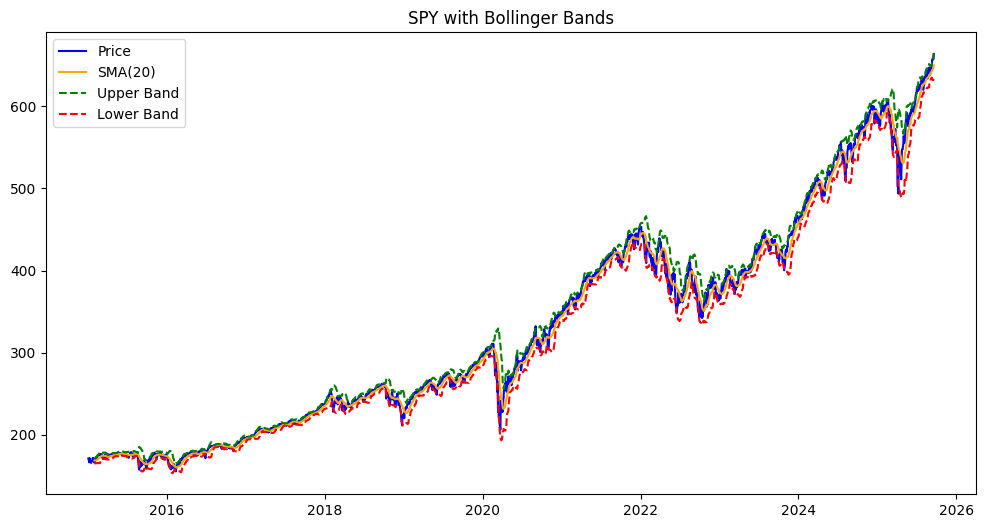

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

data = yf.download("SPY", start="2015-01-01")[["Close"]]

closedPrice = data['Close']

data['SMA'] = data['Close'].rolling(window=20).mean()

        # Calculate the 20-period Standard Deviation (SD)
data['SD'] = data['Close'].rolling(window=20).std()

        # Calculate the Upper Bollinger Band (UB) and Lower Bollinger Band (LB)
data['UB'] = data['SMA'] + 2 * data['SD']
data['LB'] = data['SMA'] - 2 * data['SD']

plt.figure(figsize=(12,6))
plt.plot(closedPrice, label="Price", color="blue")
plt.plot(data['SMA'], label="SMA(20)", color="orange")
plt.plot(data['UB'], label="Upper Band", color="green", linestyle="--")
plt.plot(data['LB'], label="Lower Band", color="red", linestyle="--")
plt.title("SPY with Bollinger Bands")
plt.legend()
plt.show()

Graph for Momentum Signal

C:\Users\matth\AppData\Local\Temp\ipykernel_25664\952927344.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SPY", start="2015-01-01")[["Close"]]
[*********************100%***********************]  1 of 1 completed


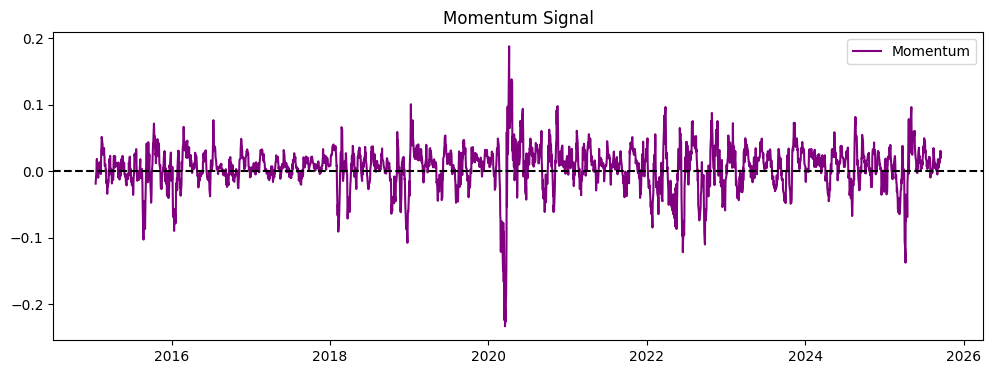

In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

data = yf.download("SPY", start="2015-01-01")[["Close"]]
data['Momentum'] = data['Close'].pct_change(periods=lookback)


plt.figure(figsize=(12,4))
plt.plot(data['Momentum'], label="Momentum", color="purple")
plt.axhline(0, color="black", linestyle="--")
plt.title("Momentum Signal")
plt.legend()
plt.show()